# **Exp8: Velocity Profile**

# Codes for the Graphs of the Data Received

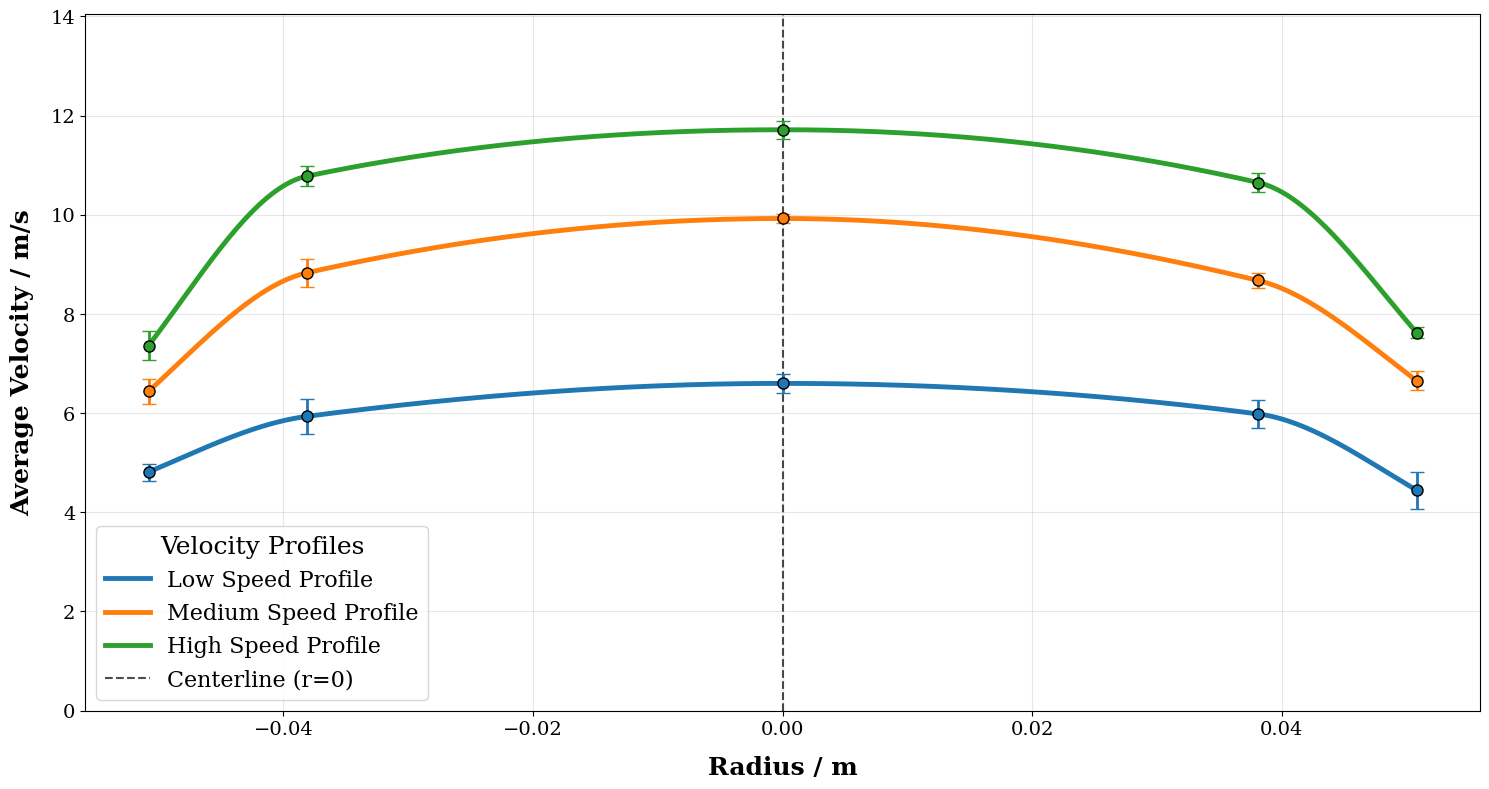

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import pchip_interpolate

# Cleaner publication style
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelweight": "bold"
})

# Load and clean the data
df = pd.read_csv("Data.csv")
df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '', regex=True)
df = df.sort_values(by='r').reset_index(drop=True)

# Define labels
speeds = [
    ('u1', 'STD1', 'Low Speed'),
    ('u2', 'STD2', 'Medium Speed'),
    ('u3', 'STD3', 'High Speed')
]

# Figure size
plt.figure(figsize=(15, 8))

# High-resolution X values
r_fine = np.linspace(df['r'].min(), df['r'].max(), 500)

for u_col, std_col, label in speeds:
    # Smooth interpolation
    u_smooth = pchip_interpolate(df['r'], df[u_col], r_fine)

    # Smooth curve
    line, = plt.plot(
        r_fine,
        u_smooth,
        linestyle='-',
        linewidth=3.5,
        label=f'{label} Profile',
        zorder=2
    )
    current_color = line.get_color()

    # Original points with error bars
    plt.errorbar(
        df['r'],
        df[u_col],
        yerr=df[std_col],
        fmt='o',
        color=current_color,
        ecolor=current_color,
        elinewidth=2.0,
        capsize=5,
        capthick=1.5,
        markersize=8,
        markeredgecolor='black',
        markeredgewidth=1.0,
        alpha=1.0,
        zorder=3
    )

# Vertical centerline
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Centerline (r=0)')

# Axis labels and ticks
plt.xlabel("Radius / m", fontsize=18, labelpad=12)
plt.ylabel("Average Velocity / m/s", fontsize=18, labelpad=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Y-axis limit
max_u = df[['u1', 'u2', 'u3']].max().max()
plt.ylim(0, max_u * 1.2)

# Grid
plt.grid(True, linestyle='-', alpha=0.3)

# Legend at bottom-left inside plot
plt.legend(
    loc='lower left',       # inside bottom-left
    fontsize=16,            # larger font
    title='Velocity Profiles',
    title_fontsize=18,
    frameon=True
)

# Extra spacing so plot doesn’t get squeezed
plt.tight_layout()

# Save high-quality figure
plt.savefig("Exp_8_1_legend_bottomleft.png", dpi=300, bbox_inches="tight")

plt.show()

In [29]:
import pandas as pd
import numpy as np
from scipy.interpolate import PchipInterpolator
from scipy.integrate import quad

# 1. Load and clean the data
df = pd.read_csv("Data.csv")
df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '', regex=True)

# Sort by radius 'r' to ensure correct interpolation
df = df.sort_values(by='r').reset_index(drop=True)

# 2. Define integration limit (Radius R)
R_limit = 0.0508

# Define the speed settings
speeds = [
    ('u1', 'Low Speed'),
    ('u2', 'Medium Speed'),
    ('u3', 'High Speed')
]

results = []

for u_col, label in speeds:
    # Create PCHIP interpolator for velocity profile u(r)
    u_interpolator = PchipInterpolator(df['r'], df[u_col])
    
    # Define the integrand: 2 * pi * r * u(r)
    def integrand(r):
        return 2 * np.pi * r * u_interpolator(r)
    
    # 3. Perform the numerical integration from 0 to R_limit
    flow_rate, _ = quad(integrand, 0, R_limit)
    
    results.append({
        'Speed Setting': label,
        'Volumetric Flow Rate (m^3/s)': round(flow_rate, 6)
    })

# 4. Create and output the results as a pandas DataFrame
flow_rate_df = pd.DataFrame(results)
flow_rate_df.to_csv("Volumetric_Flow_Rates.csv", index=False)
print(flow_rate_df)

  Speed Setting  Volumetric Flow Rate (m^3/s)
0     Low Speed                      0.047477
1  Medium Speed                      0.069814
2    High Speed                      0.084027


In [30]:
import pandas as pd
import numpy as np
from scipy.interpolate import PchipInterpolator
from scipy.integrate import quad

# 1. Load and clean the data
df = pd.read_csv("Data.csv")
df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '', regex=True)

# Sort by radius 'r' to ensure correct interpolation
df = df.sort_values(by='r').reset_index(drop=True)

# 2. Define Parameters
# Radius limit from your code (R = 0.0508 m)
R_limit = 0.0508 

# Dimensions consistent with R_limit and the 1:2 ratio in the booklet
d_tube = 2 * R_limit    # 0.1016 m
d_orifice = R_limit      # 0.0508 m (maintaining d_o = 0.5 * d_t)

rho_L = 1000             # Water density (kg/m^3)
g = 9.81                 # gravity (m/s^2)

# Area calculations
A0 = np.pi * (d_orifice**2) / 4
A1 = np.pi * (d_tube**2) / 4

# Inputs for specific speed settings
# Q1: H=4cm, rho_a=1.209 | Q2: H=9.3cm, rho_a=1.204 | Q3: H=13.2cm, rho_a=1.204
conditions = [
    {'label': 'Low Speed (Q1)', 'u_col': 'u1', 'H': 0.04, 'rho_a': 1.2090712},
    {'label': 'Medium Speed (Q2)', 'u_col': 'u2', 'H': 0.093, 'rho_a': 1.2049446},
    {'label': 'High Speed (Q3)', 'u_col': 'u3', 'H': 0.132, 'rho_a': 1.2049446}
]

results = []

for cond in conditions:
    # --- STEP 1: Calculate Actual Q using your Integration logic ---
    u_interpolator = PchipInterpolator(df['r'], df[cond['u_col']])
    
    # Integrand: 2 * pi * r * u(r)
    def integrand(r):
        return 2 * np.pi * r * u_interpolator(r)
    
    # Numerical integration from 0 to R_limit
    flow_rate, _ = quad(integrand, 0, R_limit)
    
    # --- STEP 2: Calculate Cd using Booklet Equation (2) ---
    # Formula: Q = (Cd * A0 * sqrt(2 * g * rho_L * H / rho_a)) / sqrt(1 - (A0/A1)^2)
    
    numerator_cd = flow_rate * np.sqrt(1 - (A0/A1)**2)
    denominator_cd = A0 * np.sqrt((2 * g * rho_L * cond['H']) / cond['rho_a'])
    cd_value = numerator_cd / denominator_cd
    
    results.append({
        'Speed Setting': cond['label'],
        'Actual Q (m^3/s)': round(flow_rate, 6),
        'Manometer H (m)': cond['H'],
        'Air Density (kg/m^3)': cond['rho_a'],
        'Cd Value': round(cd_value, 4)
    })

# 3. Output Results
results_df = pd.DataFrame(results)
results_df.to_csv("Final_Orifice_Results.csv", index=False)

print("--- Experimental Results ---")
print(results_df.to_string(index=False))

--- Experimental Results ---
    Speed Setting  Actual Q (m^3/s)  Manometer H (m)  Air Density (kg/m^3)  Cd Value
   Low Speed (Q1)          0.047477            0.040              1.209071    0.8902
Medium Speed (Q2)          0.069814            0.093              1.204945    0.8570
  High Speed (Q3)          0.084027            0.132              1.204945    0.8658


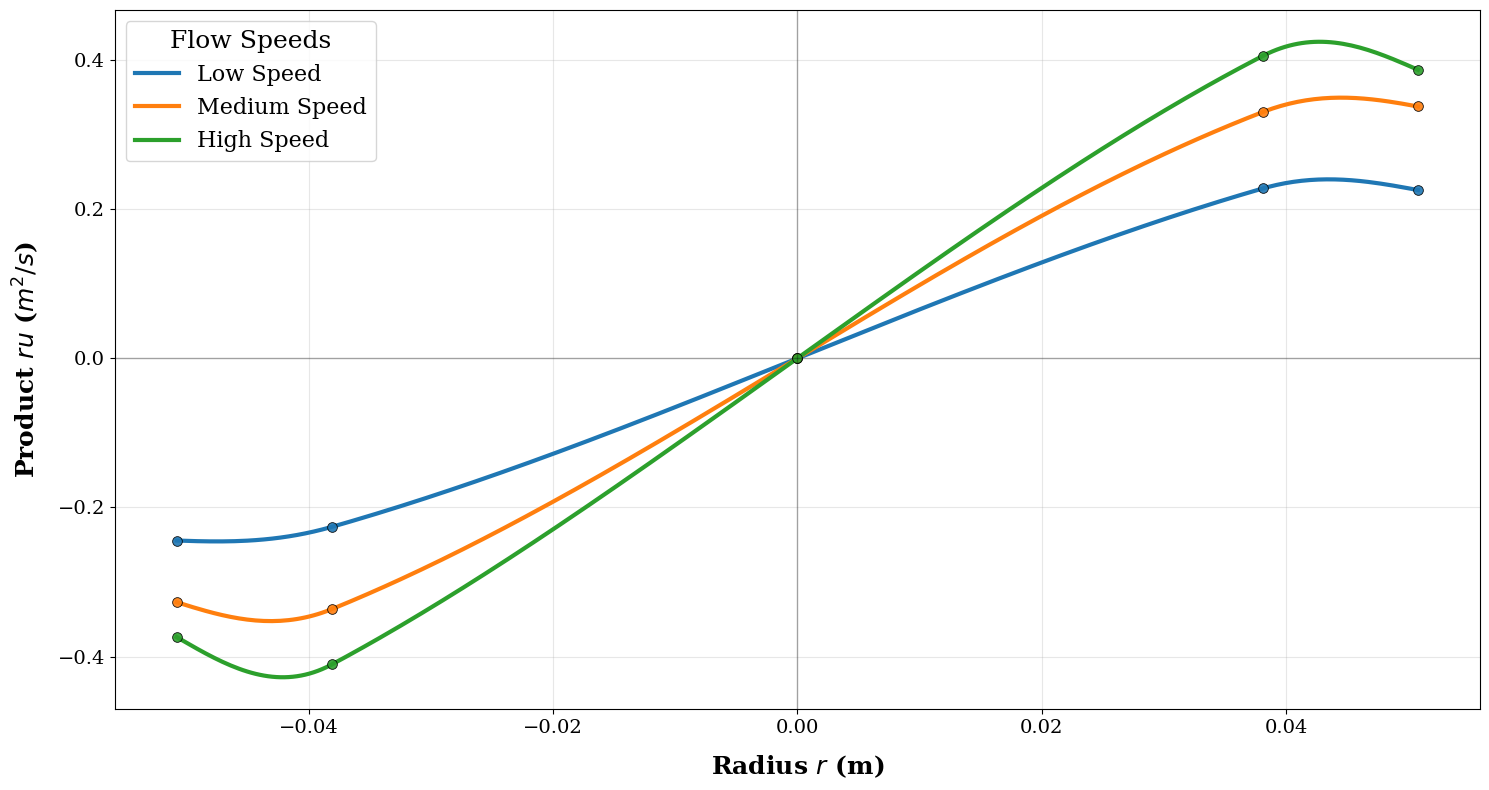

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Optional: cleaner publication style
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelweight": "bold"
})

# 1. Load and clean the data
df = pd.read_csv("Data.csv")
df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '', regex=True)
df = df.sort_values(by='r').reset_index(drop=True)

# 2. Create a dense range of r for the smooth curve
r_dense = np.linspace(df['r'].min(), df['r'].max(), 300)

# 3. Plotting Configuration
plt.figure(figsize=(15, 8))

settings = [
    {'u_col': 'u1', 'label': 'Low Speed'},
    {'u_col': 'u2', 'label': 'Medium Speed'},
    {'u_col': 'u3', 'label': 'High Speed'}
]

# Plot each profile
for item in settings:

    u_data = df[item['u_col']]
    r_data = df['r']

    # Smooth interpolator
    u_interp = PchipInterpolator(r_data, u_data)
    u_smooth = u_interp(r_dense)
    ru_smooth = r_dense * u_smooth

    # Smooth line
    line, = plt.plot(
        r_dense,
        ru_smooth,
        label=item['label'],
        linewidth=3.0
    )

    current_color = line.get_color()

    # Experimental points
    ru_actual = r_data * u_data
    plt.plot(
        r_data,
        ru_actual,
        'o',
        color=current_color,
        markersize=7,
        markeredgecolor='black',
        markeredgewidth=0.6,
        alpha=0.9,
        label='_nolegend_'
    )

# Reference axes
plt.axhline(0, color='black', linewidth=1, alpha=0.3)
plt.axvline(0, color='black', linewidth=1, alpha=0.3)

# Larger axis labels
plt.xlabel(r"Radius $r$ (m)", fontsize=18, labelpad=12)
plt.ylabel(r"Product $ru$ ($m^2/s$)", fontsize=18, labelpad=12)

# Larger ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Grid
plt.grid(True, linestyle='-', alpha=0.3)

# Bigger legend outside plot area
plt.legend(
    loc='upper left',          # Place inside upper left
    fontsize=16,               # Bigger font for visibility
    title='Flow Speeds',       # Optional bold title
    title_fontsize=18,
    frameon=True
)

# Extra margin so labels and legend don't compress plot
plt.gcf().subplots_adjust(left=0.12, bottom=0.12, right=0.85)

plt.tight_layout()

# Save high-quality image
plt.savefig(
    "smooth_ru_profile_thick_legend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
import pandas as pd
import numpy as np
from scipy.interpolate import PchipInterpolator
from scipy.integrate import quad

# 1. Constants
R_pipe = 0.0254  # Radius (m)
A_pipe = np.pi * (R_pipe**2)

# 2. Data Processing
df = pd.read_csv("Data.csv")
df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '', regex=True)
df = df.sort_values(by='r').reset_index(drop=True)

speeds = [('u1', 'Low Speed (Q1)'), ('u2', 'Medium Speed (Q2)'), ('u3', 'High Speed (Q3)')]
velocity_ratios = []

for u_col, label in speeds:
    # Find u_max at r=0
    u_max = df.loc[df['r'] == 0, u_col].values[0]
    
    # Calculate Q via integration (Positive radius only)
    df_pos = df[df['r'] >= 0]
    u_interp = PchipInterpolator(df_pos['r'], df_pos[u_col])
    flow_rate, _ = quad(lambda r: 2 * np.pi * r * u_interp(r), 0, R_pipe)
    
    # u_av from Equation 4
    u_av = flow_rate / A_pipe
    ratio = u_av / u_max
    
    velocity_ratios.append({
        'Setting': label,
        'u_max (m/s)': round(u_max, 4),
        'u_av (m/s)': round(u_av, 4),
        'Ratio': round(ratio, 4)
    })

# Output Results
results_df = pd.DataFrame(velocity_ratios)
print(results_df.to_string(index=False))

          Setting  u_max (m/s)  u_av (m/s)  Ratio
   Low Speed (Q1)       6.5981      6.4626 0.9795
Medium Speed (Q2)       9.9235      9.6280 0.9702
  High Speed (Q3)      11.7129     11.4832 0.9804
